In [40]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prevek18/ames-housing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ames-housing-dataset' dataset.
Path to dataset files: /kaggle/input/ames-housing-dataset


## Data Loading, Type Casting, and Advanced Cleaning.

In [41]:
import pandas as pd
import numpy as np

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Explanation: This cell imports the essential libraries for the project: Pandas for data manipulation, NumPy for mathematical operations, and Matplotlib/Seaborn for data visualization.

## Load Data

In [43]:
df = pd.read_csv("/kaggle/input/ames-housing-dataset/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Explanation: We load the Ames Housing dataset into a DataFrame and display the first five rows to verify the contents.

## Checking Data Shape

In [44]:
print(df.shape)

(2930, 82)


Explanation: This command returns a tuple representing the dimensionality of the DataFrame (total number of rows and columns).

# Inspecting Data Types

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

Explanation: We use this method to check the data types of each column and identify how many non-null values are present in the dataset.

# Fixing Data Types

In [46]:
df['MS SubClass'] = df['MS SubClass'].astype(str)
df['Mo Sold'] = df['Mo Sold'].astype(str)

Explanation: We convert these two columns from integers to strings because they represent categorical classifications rather than numerical measurements.

# Identifying Missing Values

In [47]:
print(df.isnull().sum().sort_values(ascending=False).head(10))

Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Lot Frontage      490
Garage Qual       159
Garage Yr Blt     159
Garage Cond       159
dtype: int64


Explanation: This step calculates the total number of missing values for each column and displays the top 10 columns with the most nulls.

# Dropping High-Null Columns

In [48]:
limit = len(df) * 0.5
df = df.dropna(thresh=limit, axis=1)

Explanation: We remove any columns that have more than 50% missing data, as they do not provide enough information for a reliable analysis.

# Filling Remaining Missing Values

In [49]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("None")

Explanation: For the remaining columns, we fill numerical gaps with the median value and categorical gaps with the label "None" to ensure a complete dataset.

# Handling Duplicate Rows

In [50]:
print(df.duplicated().sum())
df = df.drop_duplicates()

0


Explanation: We check for identical rows in the dataset and remove them to prevent biased results caused by redundant data.

# Spotting and Capping Outliers

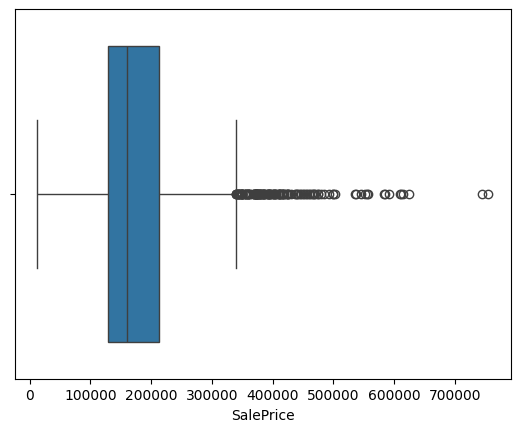

In [51]:
sns.boxplot(x=df['SalePrice'])
plt.show()

q_99 = df['SalePrice'].quantile(0.99)
df['SalePrice'] = df['SalePrice'].clip(upper=q_99)

Explanation: We visualize outliers using a boxplot. Then, we cap extreme values at the 99th percentile to minimize the influence of abnormally high prices.

# Reusable Cleaning Function

In [52]:
def clean_data(raw_data):
    data = raw_data.copy()
    data['MS SubClass'] = data['MS SubClass'].astype(str)
    data['Mo Sold'] = data['Mo Sold'].astype(str)
    data = data.dropna(thresh=len(data)*0.5, axis=1)
    data = data.drop_duplicates()

    num_vars = data.select_dtypes(include=[np.number]).columns
    data[num_vars] = data[num_vars].fillna(data[num_vars].median())

    cat_vars = data.select_dtypes(include=['object']).columns
    data[cat_vars] = data[cat_vars].fillna("None")

    data['SalePrice'] = data['SalePrice'].clip(upper=data['SalePrice'].quantile(0.99))
    return data

df_final = clean_data(df)

Explanation: This function encapsulates all the previous cleaning steps into a single, modular block of code that can be applied to any similar dataset.

# Final Validation Checks

In [53]:
assert df_final.isnull().sum().sum() == 0
assert (df_final['SalePrice'] > 0).all()
print(df_final.shape)

(2930, 77)


Explanation: These assertions perform a final check to confirm there are no missing values and that all house prices are positive, ensuring the data is ready for the next phase.

In [54]:
df_final.to_csv("cleaned_data.csv", index=False)